In [183]:
!pip install seaborn
import requests
import pandas as pd
from sklearn.model_selection import train_test_split
from sklearn.ensemble import RandomForestRegressor 
from sklearn.metrics import mean_absolute_error 
import matplotlib.pyplot as plt
import seaborn as sns

# Organizando os dados de colheita do município de Sorriso - MT (1987 - 2023)

In [184]:
url = "https://apisidra.ibge.gov.br/values/t/5457/p/all/v/112,214/c782/40124/n6/in%20n3%2051"

response = requests.get(url)

if response.status_code == 200:
    dados_brutos_colheita = response.json()
    print("Retornou", len(dados_brutos_colheita), "registros.")
    print(dados_brutos_colheita[0:2]) 
else:
    print(f"Erro na requisição: {response.status_code}")

Retornou 14383 registros.
[{'NC': 'Nível Territorial (Código)', 'NN': 'Nível Territorial', 'MC': 'Unidade de Medida (Código)', 'MN': 'Unidade de Medida', 'V': 'Valor', 'D1C': 'Ano (Código)', 'D1N': 'Ano', 'D2C': 'Variável (Código)', 'D2N': 'Variável', 'D3C': 'Produto das lavouras temporárias e permanentes (Código)', 'D3N': 'Produto das lavouras temporárias e permanentes', 'D4C': 'Município (Código)', 'D4N': 'Município'}, {'NC': '6', 'NN': 'Município', 'MC': '33', 'MN': 'Quilogramas por Hectare', 'V': '-', 'D1C': '1974', 'D1N': '1974', 'D2C': '112', 'D2N': 'Rendimento médio da produção', 'D3C': '40124', 'D3N': 'Soja (em grão)', 'D4C': '5100102', 'D4N': 'Acorizal - MT'}]


In [185]:
df_colheita = pd.DataFrame(dados_brutos_colheita[1:])
df_colheita_filtrada = df_colheita[['D1N', 'D4N', 'D2N', 'V']].rename(columns={'D1N': 'ano', 'D4N': 'municipio', 'D2N': 'variavel', 'V': 'valor'}) #D2N = Área colhida ou Qtd produzida
df_colheita_filtrada['valor'] = pd.to_numeric(df_colheita_filtrada['valor'], errors='coerce')

In [186]:
df_colheita_pivotada = df_colheita_filtrada.pivot_table(
    index=['municipio', 'ano'], # quais colunas identificam uma única linha
    columns='variavel',      # qual coluna cujo conteúdo vira cabeçalho
    values='valor'        # 3. qual coluna tem o conteúdo que irá preencher a tabela pivo
).reset_index()

df_colheita_pivotada.columns.name = None
df_colheita_pivotada['ano'] = df_colheita_pivotada['ano'].astype(int)
df_colheita_pivotada.sort_values(by=['municipio', 'ano'], inplace=True)
df_colheita_pivotada = df_colheita_pivotada[df_colheita_pivotada['municipio'] == 'Sorriso - MT'] # separando só pelo municípo de sorriso 

serie_colheita_2024 = df_colheita_pivotada[-1:]# serie da colheita de 2024 para previsão posterior
df_colheita_pivotada = df_colheita_pivotada[:-1] # dataframe da colheita de 1987 até 2023


# Organizando os dados de precipitação - Sorriso - MT (1987 - 2023)

In [187]:
lat, lon = -12.54, -55.72 # Coordenadas aproximadas do município
start_date, end_date = "19870101", "20241231"

# Url da api do projeto power.larc.nasa
url = f"https://power.larc.nasa.gov/api/temporal/daily/point?parameters=PRECTOTCORR&community=RE&longitude={lon}&latitude={lat}&start={start_date}&end={end_date}&format=JSON"

response = requests.get(url)
dados_nasa = response.json()

In [188]:
df_clima_satelite = pd.DataFrame(list(dados_nasa['properties']['parameter']['PRECTOTCORR'].items()), columns=['Data', 'Chuva_mm'])

df_clima_satelite['Data'] = pd.to_datetime(df_clima_satelite['Data'])
df_clima_satelite['ano'] = df_clima_satelite['Data'].dt.year
df_clima_satelite['mes'] = df_clima_satelite['Data'].dt.month

df_clima_satelite.head(10)

,Data,Chuva_mm,ano,mes
0,1987-01-01,3.17,1987,1
1,1987-01-02,5.98,1987,1
2,1987-01-03,2.08,1987,1
3,1987-01-04,8.61,1987,1
4,1987-01-05,0.98,1987,1
5,1987-01-06,0.25,1987,1
6,1987-01-07,4.06,1987,1
7,1987-01-08,1.18,1987,1
8,1987-01-09,4.35,1987,1
9,1987-01-10,1.20,1987,1


In [189]:
df_clima_agrupado = df_clima_satelite.groupby(['ano', 'mes'])['Chuva_mm'].sum().reset_index() #pegando a chuva acumulada por ano
df_clima_pivotada = df_clima_agrupado.pivot_table(index='ano', columns='mes', values='Chuva_mm').reset_index()

df_clima_pivotada .insert(0, 'municipio', 'Sorriso - MT')
df_clima_pivotada .columns.name = None

serie_clima_2024 = df_clima_pivotada[-1:] #serie com os dados de 2024 para tentativa de previsão

df_clima_pivotada = df_clima_pivotada[:-1] #dataframe da precipitação mensal até 2023

display(df_clima_pivotada)

display(serie_clima_2024)

,municipio,ano,1,2,3,4,5,6,7,8,9,10,11,12
0,Sorriso - MT,1987,215.47,274.88,204.11,102.32,35.20,0.96,0.00,0.62,27.54,103.97,345.89,311.15
1,Sorriso - MT,1988,257.28,420.47,257.03,127.69,9.58,1.43,0.00,0.00,0.72,183.22,217.10,374.56
2,Sorriso - MT,1989,276.78,243.50,372.23,131.88,31.40,28.05,16.78,44.29,47.41,114.31,135.71,400.64
3,Sorriso - MT,1990,321.90,374.77,147.09,166.34,53.87,0.12,2.51,22.05,130.56,184.89,171.98,328.29
4,Sorriso - MT,1991,486.72,344.31,314.70,197.38,40.34,0.42,0.02,0.06,102.83,134.16,234.21,217.34
5,Sorriso - MT,1992,454.12,442.35,339.45,183.11,8.51,2.33,0.00,38.63,150.90,194.25,246.62,349.61
6,Sorriso - MT,1993,198.17,350.48,151.33,115.23,8.51,12.49,0.01,24.61,57.33,146.25,253.57,392.00
7,Sorriso - MT,1994,395.92,296.01,377.02,185.33,25.09,48.07,13.05,5.43,40.02,210.51,252.60,363.68
8,Sorriso - MT,1995,379.01,403.48,245.24,206.42,75.21,10.44,0.00,0.05,23.42,115.79,281.96,289.71
9,Sorriso - MT,1996,295.53,230.11,135.82,204.49,29.84,0.54,0.00,20.61,62.61,128.33,225.54,241.03


,municipio,ano,1,2,3,4,5,6,7,8,9,10,11,12
37,Sorriso - MT,2024,303.83,252.42,178.18,176.39,27.37,25.89,27.05,2.22,11.27,130.99,215.61,118.69


# Criando o dataset final

In [190]:
dataset_final = pd.merge(df_colheita_pivotada,df_clima_pivotada, on='ano', how='left')
dataset_final.info()

<class 'pandas.DataFrame'>
RangeIndex: 37 entries, 0 to 36
Data columns (total 17 columns):
 #   Column                        Non-Null Count  Dtype  
---  ------                        --------------  -----  
 0   municipio_x                   37 non-null     str    
 1   ano                           37 non-null     int64  
 2   Quantidade produzida          37 non-null     float64
 3   Rendimento médio da produção  37 non-null     float64
 4   municipio_y                   37 non-null     str    
 5   1                             37 non-null     float64
 6   2                             37 non-null     float64
 7   3                             37 non-null     float64
 8   4                             37 non-null     float64
 9   5                             37 non-null     float64
 10  6                             37 non-null     float64
 11  7                             37 non-null     float64
 12  8                             37 non-null     float64
 13  9                 

# Treinamento do modelo para previsão de rendimento médio da produção de soja (1987 - 2023)

In [191]:
features = dataset_final.drop(columns=['Rendimento médio da produção', 'municipio_x', 'ano', 'Quantidade produzida', 'municipio_y']) 
target = dataset_final['Rendimento médio da produção']

In [192]:
X_train, X_test, y_train, y_test = train_test_split(features, target, test_size=0.20, random_state=42)

In [193]:
regressor = RandomForestRegressor(n_estimators=100, random_state=42)
regressor.fit(X_train, y_train)
y_pred = regressor.predict(X_test)

In [194]:
mae = mean_absolute_error(y_test, y_pred)
r2 = regressor.score(X_test, y_test) # R^2 score
print(f"Erro absoluto: {mae}")
print(f"R^2 Score: {r2}") #

Erro absoluto: 351.53125000000006
R^2 Score: 0.01975094155111856


In [195]:
# considerações: o modelo está errando por 350 kg por hectare (não tão ruim) porém o R² está muito baixo, indicando o mal entendimento dos dados pelo modelo

# Ajuste da tabela final e treinamento para aumentar coeficiente de determinação (R²)

In [196]:
dataset_ajustado = dataset_final

In [197]:
dataset_ajustado['periodo de plantio'] = dataset_ajustado[[9, 10, 11]].sum(axis=1) # aqui eu peguei o período do início de chuva, e início dos plantios
dataset_ajustado['periodo de seca'] = dataset_ajustado[[6, 7, 8]].sum(axis=1) # período de menor incidencia de chuva
dataset_ajustado['periodo de enchimento dos grãos'] = dataset_ajustado[[12, 1, 2, 3]].sum(axis=1) # período (fases reprodutivas R5 a R6) de enchimento das vagens e grãos 
dataset_ajustado = dataset_ajustado[['periodo de plantio', 'periodo de seca', 'periodo de enchimento dos grãos']]
dataset_ajustado

,periodo de plantio,periodo de seca,periodo de enchimento dos grãos
0,477.40,1.58,1005.61
1,401.04,1.43,1309.34
2,297.43,89.12,1293.15
3,487.43,24.68,1172.05
4,471.20,0.50,1363.07
5,591.77,40.96,1585.53
6,457.15,37.11,1091.98
7,503.13,66.55,1432.63
8,421.17,10.49,1317.44
9,416.48,21.15,902.49


In [198]:
features_novas = dataset_ajustado

In [199]:
# treinamento do modelo
X_train, X_test, y_train, y_test = train_test_split(features_novas, target, test_size=0.20, random_state=42)
regressor = RandomForestRegressor(n_estimators=100, random_state=42)
regressor.fit(X_train, y_train)
y_pred = regressor.predict(X_test)

In [200]:
# avaliando modelo
mae = mean_absolute_error(y_test, y_pred)
r2 = regressor.score(X_test, y_test) # R^2 score
print(f"Erro absoluto: {mae}")
print(f"R^2 Score: {r2}")

Erro absoluto: 283.47999999999996
R^2 Score: 0.3151479735565972


# Tentando prever o rendimento médio da produção 2024

In [201]:
serie_clima_2024.head()

,municipio,ano,1,2,3,4,5,6,7,8,9,10,11,12
37,Sorriso - MT,2024,303.83,252.42,178.18,176.39,27.37,25.89,27.05,2.22,11.27,130.99,215.61,118.69


In [202]:
serie_clima_2024['periodo de plantio'] = serie_clima_2024[[9, 10, 11]].sum(axis=1)
serie_clima_2024['periodo de seca'] = serie_clima_2024[[6, 7, 8]].sum(axis=1)
serie_clima_2024['periodo de enchimento dos grãos'] = serie_clima_2024[[12, 1, 2, 3]].sum(axis=1)

serie_clima_2024 = serie_clima_2024[['periodo de plantio', 'periodo de seca', 'periodo de enchimento dos grãos']]


In [203]:
previsao = regressor.predict(serie_clima_2024)
previsao_2024 = float(previsao[0])

In [204]:
diferenca = serie_colheita_2024['Rendimento médio da produção'] - float(previsao_2024)

In [205]:
diferenca

3157    141.61
Name: Rendimento médio da produção, dtype: float64

In [206]:
#nota-se que erramos por 141.61 kg / por hectare, dentro da nossa margem de erro

# Vizualizando a previsão histórica do modelo vs a produtividade real ao longo dos anos

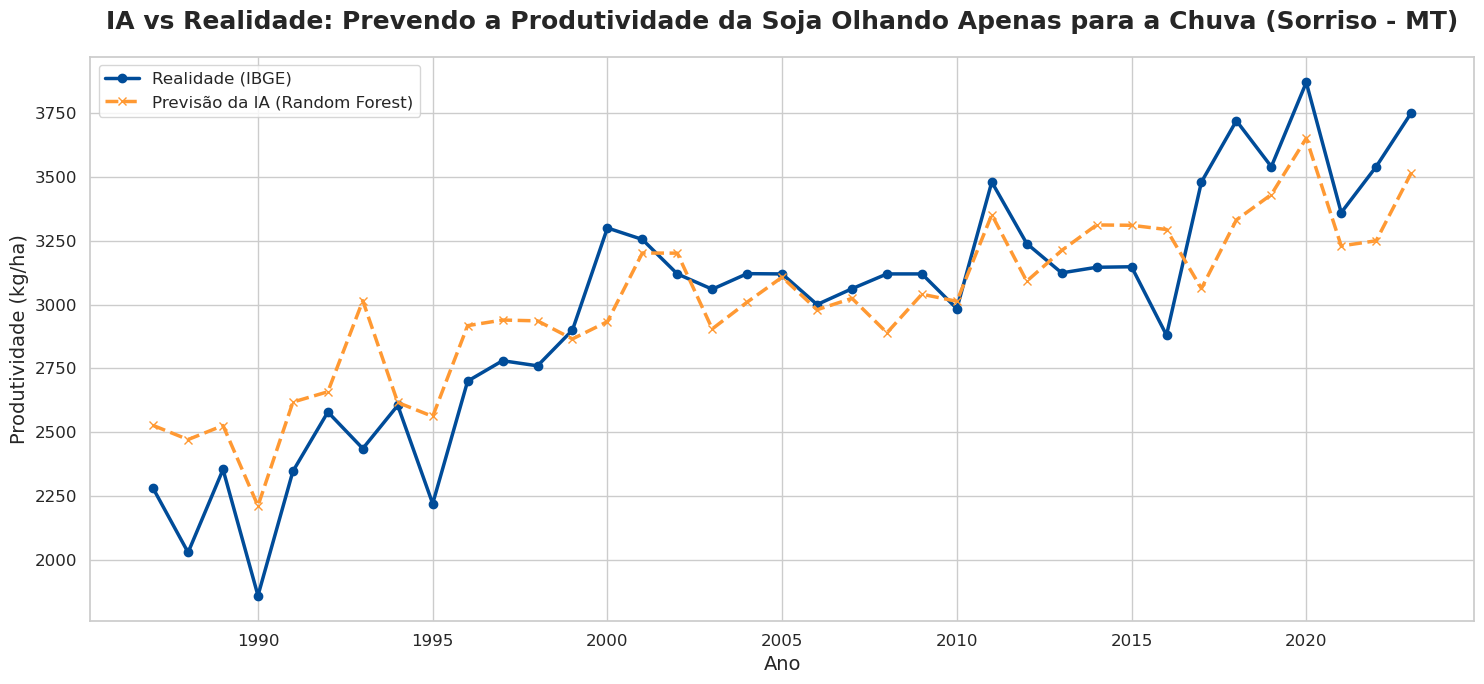

In [210]:
previsoes_historicas = regressor.predict(features_novas)


eixo_x = dataset_final['ano']
linha_real = dataset_final['Rendimento médio da produção']

sns.set_theme(style="whitegrid")
plt.figure(figsize=(15, 7))


plt.plot(eixo_x, linha_real, label='Realidade (IBGE)', color='#004c99', linewidth=2.5, marker='o')


plt.plot(eixo_x, previsoes_historicas, label='Previsão da IA (Random Forest)', color='#ff9933', linewidth=2.5, linestyle='--', marker='x')


plt.title("IA vs Realidade: Prevendo a Produtividade da Soja Olhando Apenas para a Chuva (Sorriso - MT)", fontsize=18, fontweight='bold', pad=20)
plt.xlabel("Ano", fontsize=14)
plt.ylabel("Produtividade (kg/ha)", fontsize=14)

plt.legend(fontsize=12, loc='upper left')
plt.xticks(fontsize=12)
plt.yticks(fontsize=12)

plt.tight_layout()
plt.savefig('grafico_previsao_soja_mt.png', dpi=300, bbox_inches='tight')
plt.show()

# Salva o gráfico em alta resolução
